# CICIDS2017 -> functional curves -> penalized Hotelling test $T_n^2(\alpha)$

We compare **BENIGN** traffic (Monday, an ordinary day) to traffic during the **DDoS attack
window** (Friday afternoon), treating each group of flows as a sample of functional curves.

**Construction of individuals.** Each individual = `P_GRID` consecutive values of
`log(1 + Flow Bytes/s)` (transformation applied **globally**, before any splitting: no individual
standardization per window, which would erase the mean-level difference between BENIGN and attack
that the test is meant to detect).

**Parity correction (see Steps 2a-2c).** An exploratory diagnostic revealed a checkerboard
pattern (period 2) in the covariance operator of the attack group. A second diagnostic ruled out
the hypothesis of a row-by-row BENIGN/DDoS interleaving in the raw file (labels are grouped in
blocks, not alternating), but confirmed a strong residual autocorrelation at lag 2 *within* flows
of the same label: two sub-processes alternate every other row (most likely the forward/backward
direction of the same connection, or a cycling artifact of the DDoS generator). We correct this by
de-interleaving each sequence (BENIGN, attack) by parity before windowing, to obtain genuinely
homogeneous windows.

**Independence.** Non-overlapping windows within each parity stream; shuffle after extraction.

## Outline
1. Imports, loading, cleaning (Steps 1a-1c)
2. Two diagnostic cells: exploration (2a), then statistics justifying the correction (2b)
3. Final, corrected, construction of X and Y (Step 2c)
4. Visualization (4x2 panel: curves+mean, covariance operator, eigenvalues, eigenfunctions - X on the left, Y on the right) (Step 3)
5. Test functions ($T_n^2(\alpha)$, Theorem 2.2 bound, Ledoit-Wolf penalty, sign-flip permutation) (Step 4)
6. Test at fixed $\alpha$ (Step 5)
7. Sensitivity of $T_n^2(\alpha)$, $B_n(\alpha)$ and the permutation mean to $\alpha$ (Step 6)


## Step 1a. Imports and parameters

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

# ---- free parameters, feel free to change ----
P_GRID = 50          # p: number of points (flows) per individual / window
DELTA  = 0.05        # test level (Theorem 2.2)
ALPHA_FIXED = 1.0    # penalty alpha used in step 5 (feel free to change)
SEED = 0


## Step 1b. Data

Mount Google Drive and point to your `MachineLearningCSV` files
(`Monday-WorkingHours.pcap_ISCX.csv` for the ordinary day,
`Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` for the DDoS window).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BENIGN_CSV_PATH = "/content/drive/MyDrive/1/Monday-WorkingHours.pcap_ISCX.csv"
ATTACK_CSV_PATH = "/content/drive/MyDrive/1/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"


Mounted at /content/drive


## Step 1c. Loading and cleaning (no windowing yet)

- concatenates BENIGN + attack while preserving order (chronological proxy)
- cleans column names (`str.strip()`)
- removes `inf` / `NaN`, keeps only `Flow Bytes/s >= 0`
- transforms **globally** with `log1p`
- splits the sequence into two homogeneous sub-sequences by label (BENIGN / attack), each in its
  original chronological order - **the actual windowing comes later**, once the parity correction
  is established (Steps 2a-2c).

In [ ]:
# -----------------------------
# 1. Loading
# -----------------------------
benign_df = pd.read_csv(BENIGN_CSV_PATH)
attack_df = pd.read_csv(ATTACK_CSV_PATH)

df = pd.concat([benign_df, attack_df], ignore_index=True)

# -----------------------------
# 2. Column cleaning
# -----------------------------
df.columns = df.columns.str.strip()

if "Label" not in df.columns:
    raise ValueError("Column 'Label' not found. Check the exact name.")

# -----------------------------
# 3. Data cleaning
# -----------------------------
df = df.replace([np.inf, -np.inf], np.nan).dropna()

feature = "Flow Bytes/s"
if feature not in df.columns:
    raise ValueError(f"Feature '{feature}' not found.")

df = df[df[feature] >= 0].reset_index(drop=True)

# -----------------------------
# 4. GLOBAL transformation (no per-window standardization)
# -----------------------------
df["log_rate"] = np.log1p(df[feature].values)

values = df["log_rate"].values
labels = df["Label"].values

# -----------------------------
# 5. Split by label (chronological order preserved within each group)
# -----------------------------
is_benign = labels == "BENIGN"
benign_seq = values[is_benign]
attack_seq = values[~is_benign]

p = P_GRID
print("BENIGN flows  (cleaned, chronological):", benign_seq.shape[0])
print("Attack flows  (cleaned, chronological):", attack_seq.shape[0])


BENIGN flows  (cleaned, chronological): 627156
Attack flows  (cleaned, chronological): 128025


## Step 2a. Diagnostic (1/2) - exploration of naively built curves

Before any correction, we window naively (consecutive blocks of `p` points, without handling
parity) just to **visualize** the structure. A 6-view panel (one figure per group): a single
curve, the first 5 curves, 10 random curves, the last 5 curves, mean +/- 1 standard deviation,
and a heatmap of all stacked windows. These "naive" windows are *not* the ones used for the
final test (see Step 2c).

Naive windows (diagnostic only): X_naive (12543, 50)  Y_naive (2560, 50)


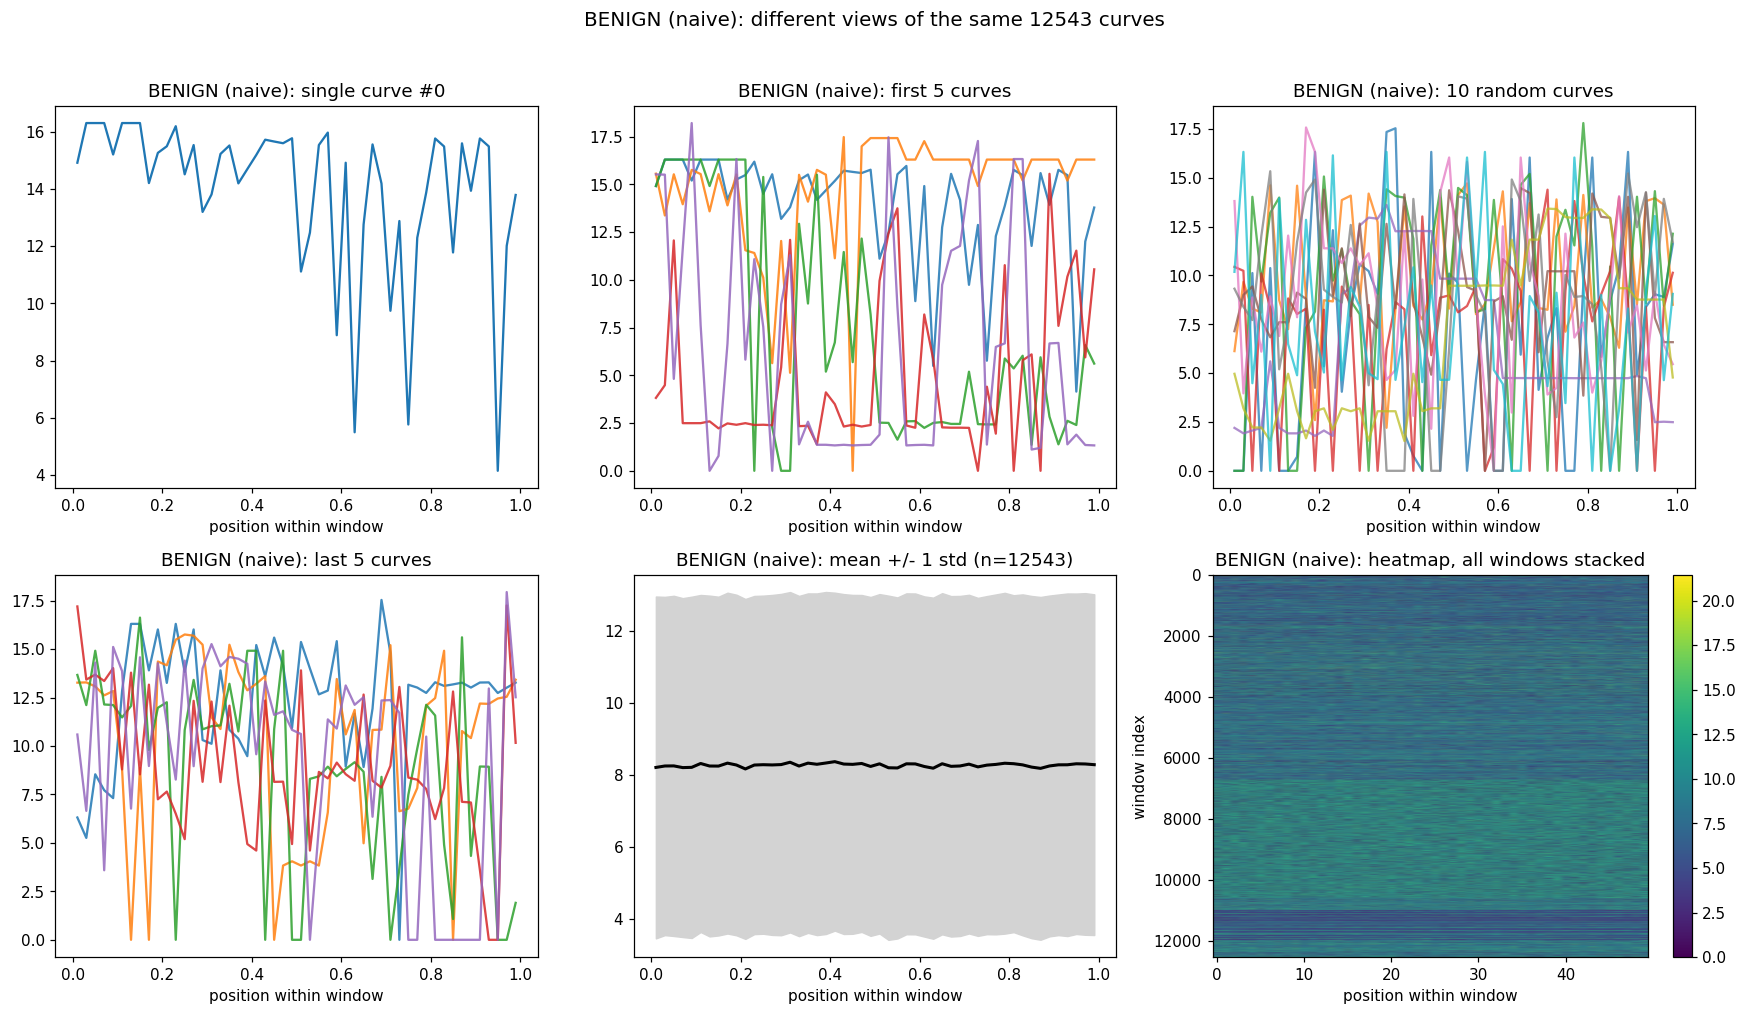

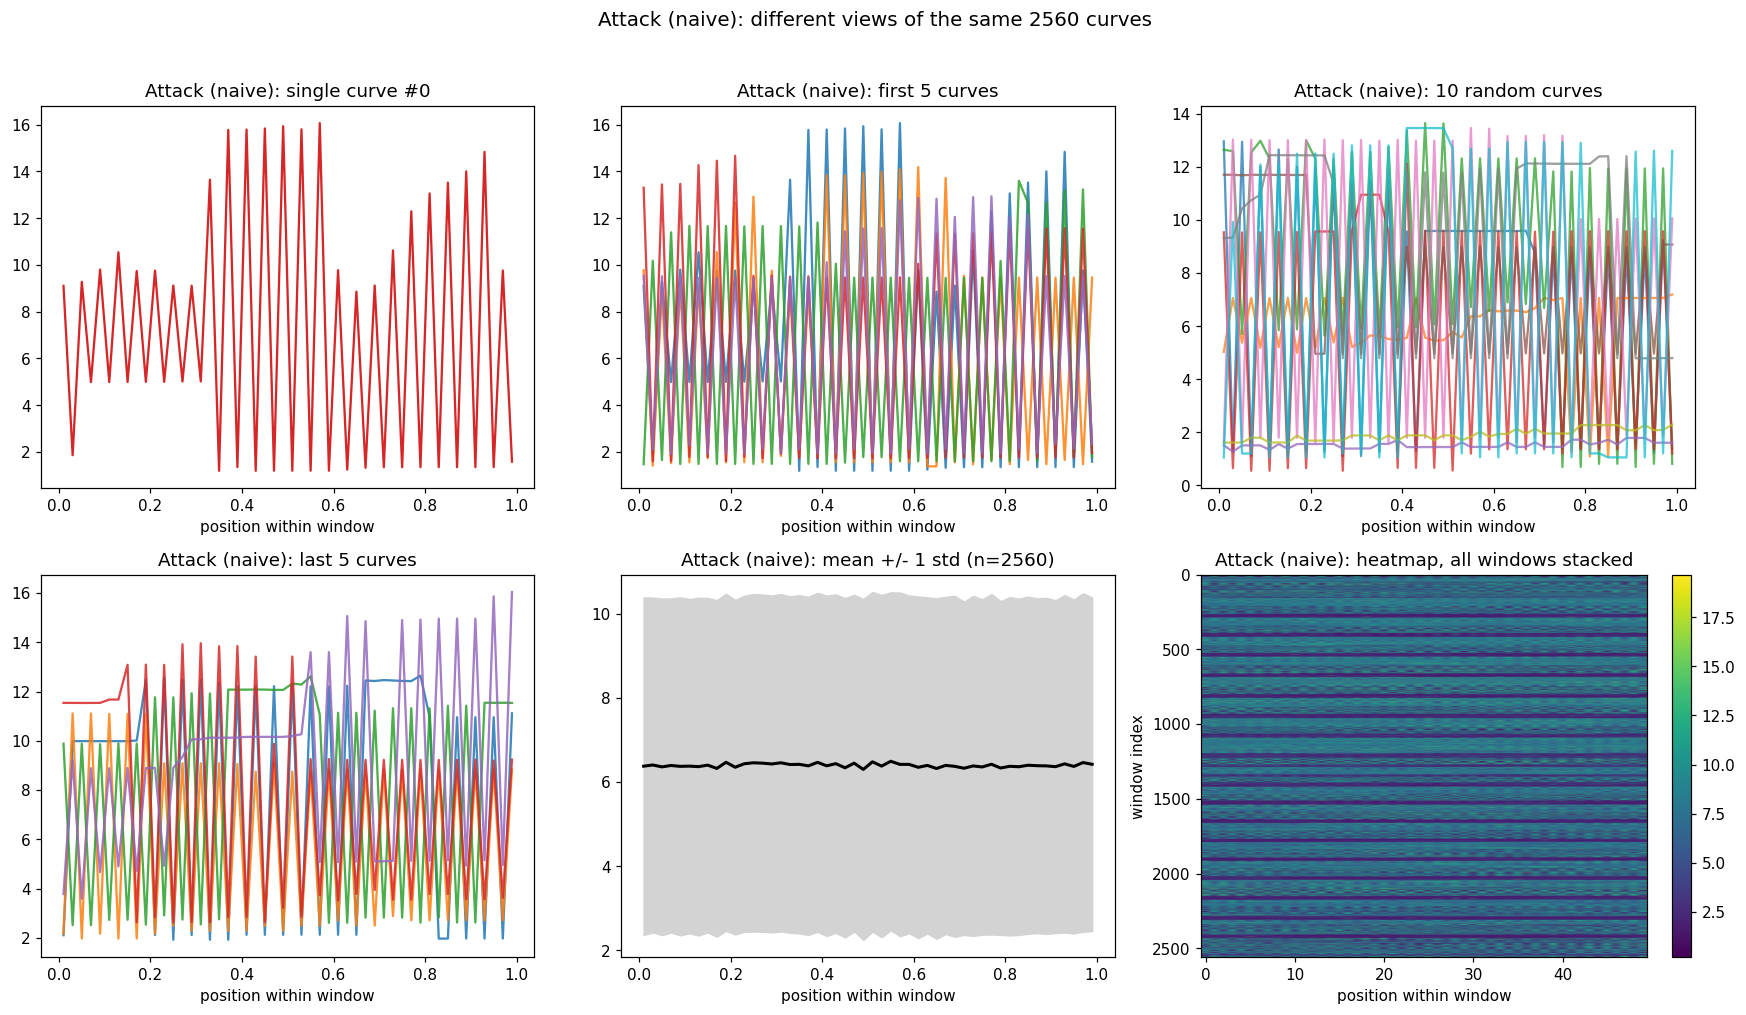

In [ ]:
def naive_windows(seq: np.ndarray, p: int) -> np.ndarray:
    """Naive windowing: consecutive blocks of p points, without handling parity."""
    n_win = len(seq) // p
    if n_win == 0:
        return np.empty((0, p))
    return np.array([seq[i * p:(i + 1) * p] for i in range(n_win)])


def plot_group_exploration(Z: np.ndarray, name: str, color: str = "steelblue", seed: int = 0):
    n, p_ = Z.shape
    t = (np.arange(1, p_ + 1) - 0.5) / p_
    rng_view = np.random.default_rng(seed)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    ax = axes[0, 0]
    ax.plot(t, Z[0], color=color)
    ax.set_title(f"{name}: single curve #0")
    ax.set_xlabel("position within window")

    ax = axes[0, 1]
    for i in range(min(5, n)):
        ax.plot(t, Z[i], alpha=0.85)
    ax.set_title(f"{name}: first 5 curves")
    ax.set_xlabel("position within window")

    ax = axes[0, 2]
    idx = rng_view.choice(n, size=min(10, n), replace=False)
    for i in idx:
        ax.plot(t, Z[i], alpha=0.75)
    ax.set_title(f"{name}: 10 random curves")
    ax.set_xlabel("position within window")

    ax = axes[1, 0]
    for i in range(max(0, n - 5), n):
        ax.plot(t, Z[i], alpha=0.85)
    ax.set_title(f"{name}: last 5 curves")
    ax.set_xlabel("position within window")

    ax = axes[1, 1]
    mean_curve, std_curve = Z.mean(axis=0), Z.std(axis=0)
    ax.fill_between(t, mean_curve - std_curve, mean_curve + std_curve, color="lightgray")
    ax.plot(t, mean_curve, color="black", lw=2)
    ax.set_title(f"{name}: mean +/- 1 std (n={n})")
    ax.set_xlabel("position within window")

    ax = axes[1, 2]
    im = ax.imshow(Z, aspect="auto", cmap="viridis")
    ax.set_title(f"{name}: heatmap, all windows stacked")
    ax.set_xlabel("position within window"); ax.set_ylabel("window index")
    fig.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(f"{name}: different views of the same {n} curves", y=1.02, fontsize=13)
    fig.tight_layout()
    plt.show()


X_naive = naive_windows(benign_seq, p)
Y_naive = naive_windows(attack_seq, p)
print("Naive windows (diagnostic only): X_naive", X_naive.shape, " Y_naive", Y_naive.shape)

plot_group_exploration(X_naive, "BENIGN (naive)", color="tab:blue", seed=1)
plot_group_exploration(Y_naive, "Attack (naive)", color="tab:red", seed=1)


## Step 2b. Diagnostic (2/2) - where does the checkerboard come from, and does it need fixing?

Two independent checks:

1. **Empirical autocorrelation of `log_rate`** at small lags, on `benign_seq` and `attack_seq`
   (before any windowing). A strong autocorrelation alternating in sign (or concentrated on even
   lags) is the signature of a period-2 pattern in the row order itself.
2. **Row-by-row label transition rate** in the raw Friday file (before cleaning), and label
   composition of even vs odd positions - to check whether the checkerboard comes from a
   BENIGN/DDoS interleaving, or from something else.

The cell automatically concludes on the correction to apply.

Autocorrelation of log_rate - ATTACK flows:
  lag 1: -0.1154
  lag 2: +0.8768
  lag 3: -0.0959
  lag 4: +0.7920

Autocorrelation of log_rate - BENIGN flows:
  lag 1: +0.2311
  lag 2: +0.1979
  lag 3: +0.1763
  lag 4: +0.1624


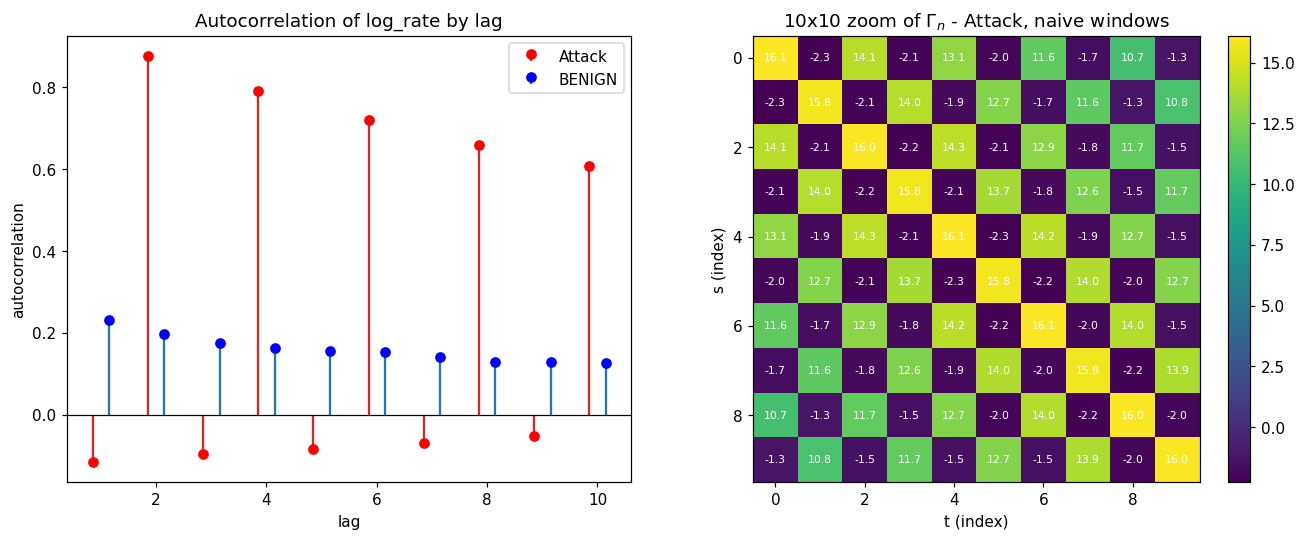


Row-by-row Label transition rate (raw Friday file): 0.000
  (close to 1 = near-systematic alternation; close to 0 = labels grouped in blocks)

Label composition of EVEN positions (raw file): {'DDoS': 0.567, 'BENIGN': 0.433}
Label composition of ODD positions  (raw file): {'DDoS': 0.567, 'BENIGN': 0.433}

--- Conclusion ---
The checkerboard is NOT due to a BENIGN/DDoS alternation (labels are grouped in blocks: transition rate = 0.000, identical composition at even/odd positions). Instead, the autocorrelation remains strong and concentrated on even lags even WITHIN flows sharing the same label: two sub-processes alternate every other row in the raw file (e.g. the forward/backward direction of the same connection, or a cycling artifact of the DDoS generator). Correction adopted: de-interleave each sequence (BENIGN and attack) by parity before windowing - see Step 2c.


In [ ]:
def eigendecomp(Z: np.ndarray):
    n, p_ = Z.shape
    Zc = Z - Z.mean(axis=0)
    Gamma = (Zc.T @ Zc) / n
    eigvals, eigvecs = np.linalg.eigh(Gamma)
    order = np.argsort(eigvals)[::-1]
    return Gamma, np.clip(eigvals[order], 0.0, None), eigvecs[:, order]


def autocorr_lag(x: np.ndarray, lag: int) -> float:
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    den = np.sum(x ** 2)
    return float(np.sum(x[:n - lag] * x[lag:]) / den) if den > 0 else np.nan


# ---- 1. autocorrelation ----
Gamma_Y_naive, lam_Y_naive, U_Y_naive = eigendecomp(Y_naive)

lags = np.arange(1, 11)
ac_attack = [autocorr_lag(attack_seq, l) for l in lags]
ac_benign = [autocorr_lag(benign_seq, l) for l in lags]

print("Autocorrelation of log_rate - ATTACK flows:")
for l, a in zip(lags[:4], ac_attack[:4]):
    print(f"  lag {l}: {a:+.4f}")
print("\nAutocorrelation of log_rate - BENIGN flows:")
for l, a in zip(lags[:4], ac_benign[:4]):
    print(f"  lag {l}: {a:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.stem(lags - 0.15, ac_attack, linefmt="tab:red", markerfmt="ro", basefmt=" ", label="Attack")
ax.stem(lags + 0.15, ac_benign, linefmt="tab:blue", markerfmt="bo", basefmt=" ", label="BENIGN")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("lag"); ax.set_ylabel("autocorrelation")
ax.set_title("Autocorrelation of log_rate by lag")
ax.legend()

ax = axes[1]
zoom = Gamma_Y_naive[:10, :10]
im = ax.imshow(zoom, cmap="viridis")
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{zoom[i, j]:.1f}", ha="center", va="center", color="white", fontsize=7)
ax.set_title(fr"10x10 zoom of $\Gamma_n$ - Attack, naive windows")
ax.set_xlabel("t (index)"); ax.set_ylabel("s (index)")
fig.colorbar(im, ax=ax, fraction=0.046)

fig.tight_layout()
plt.show()

# ---- 2. is there a label interleaving in the raw Friday file? ----
attack_raw = attack_df.copy()
attack_raw.columns = attack_raw.columns.str.strip()
labels_raw = attack_raw["Label"].astype(str).str.strip().values

transition_rate = float(np.mean(labels_raw[:-1] != labels_raw[1:]))
print(f"\nRow-by-row Label transition rate (raw Friday file): {transition_rate:.3f}")
print("  (close to 1 = near-systematic alternation; close to 0 = labels grouped in blocks)")

even_labels, odd_labels = labels_raw[0::2], labels_raw[1::2]
comp_even = pd.Series(even_labels).value_counts(normalize=True).round(3)
comp_odd = pd.Series(odd_labels).value_counts(normalize=True).round(3)
print("\nLabel composition of EVEN positions (raw file):", comp_even.to_dict())
print("Label composition of ODD positions  (raw file):", comp_odd.to_dict())

# ---- automatic conclusion ----
lag2_strong = abs(ac_attack[1]) > 0.5          # lags[1] corresponds to lag = 2
labels_interleaved = transition_rate > 0.5

print("\n--- Conclusion ---")
if lag2_strong and not labels_interleaved:
    print("The checkerboard is NOT due to a BENIGN/DDoS alternation (labels are grouped in "
          f"blocks: transition rate = {transition_rate:.3f}, identical composition at even/odd "
          "positions). Instead, the autocorrelation remains strong and concentrated on even "
          "lags even WITHIN flows sharing the same label: two sub-processes alternate every "
          "other row in the raw file (e.g. the forward/backward direction of the same "
          "connection, or a cycling artifact of the DDoS generator). "
          "Correction adopted: de-interleave each sequence (BENIGN and attack) by parity "
          "before windowing - see Step 2c.")
elif lag2_strong and labels_interleaved:
    print("BENIGN/DDoS labels alternate almost systematically row by row in the raw file "
          f"(transition rate = {transition_rate:.3f}): this is the direct cause of the "
          "checkerboard. Correction adopted: separate BENIGN and DDoS by label BEFORE any "
          "windowing (already done since Step 1c), then de-interleave by parity if the "
          "pattern persists within each label - see Step 2c.")
else:
    print("No clear even/odd interleaving signature detected on this data - the parity "
          "correction may not be necessary here; check on a case-by-case basis before "
          "windowing.")


## Step 2c. Final, corrected, construction of X and Y

We de-interleave each homogeneous sequence (`benign_seq`, `attack_seq`) by parity: even and odd
positions are split into two independent chronological sub-sequences, each is windowed
**separately** (non-overlapping blocks of size `p`), and the windows from both parities are then
pooled to form the final group. This removes the interleaving identified in step 2b, for both
groups (applied uniformly to X and Y, for symmetry and as a precaution). Independent shuffle of
X and Y after extraction.

In [ ]:
def build_deinterleaved_windows(seq: np.ndarray, p: int) -> np.ndarray:
    """Splits seq into 2 sub-sequences (even / odd indices), windows each one separately
    (non-overlapping windows of size p), then pools the windows from both streams."""
    windows = []
    for sub in (seq[0::2], seq[1::2]):
        n_win = len(sub) // p
        for i in range(n_win):
            windows.append(sub[i * p:(i + 1) * p])
    return np.array(windows) if windows else np.empty((0, p))


X = build_deinterleaved_windows(benign_seq, p)
Y = build_deinterleaved_windows(attack_seq, p)

rng0 = np.random.default_rng(SEED)
X = X[rng0.permutation(len(X))]
Y = Y[rng0.permutation(len(Y))]

print("X (BENIGN, corrected):", X.shape)
print("Y (attack, corrected):", Y.shape)


X (BENIGN, corrected): (12542, 50)
Y (attack, corrected): (2560, 50)


## Step 3. Visualization - functional structure of X and Y (corrected)

4-row x 2-column panel (X = BENIGN on the left, Y = attack on the right):
1. sample curves + mean curve
2. empirical covariance operator $\Gamma_n$ (heatmap)
3. decay of the eigenvalues of $\Gamma_n$
4. first 5 empirical eigenfunctions

If the parity correction worked, the checkerboard from step 2b should have disappeared from the
covariance operator of Y.

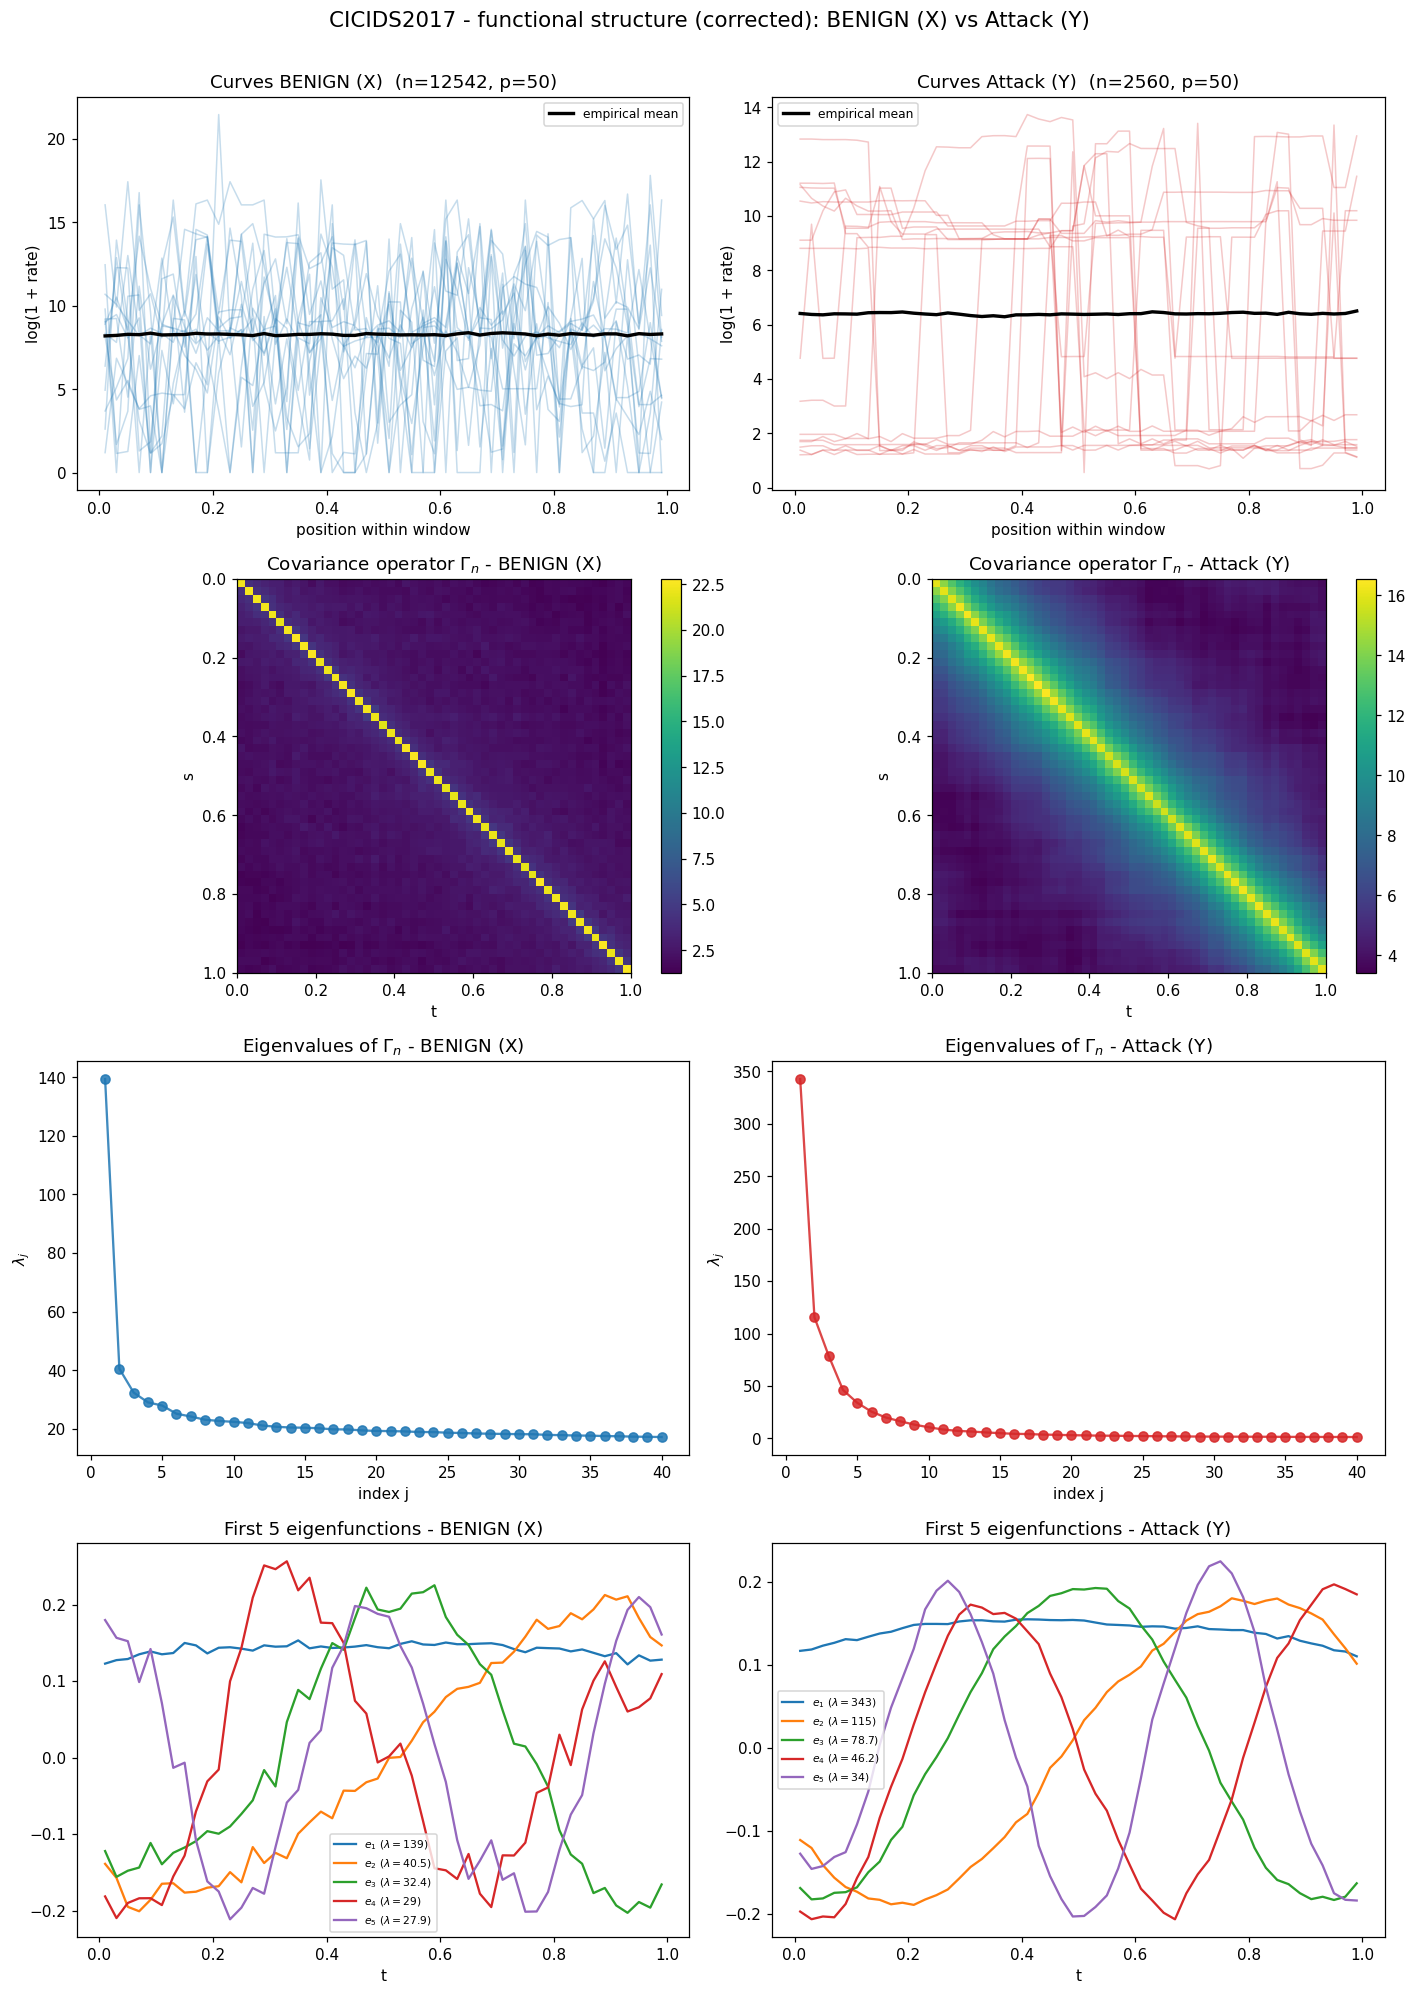

In [ ]:
Gamma_X, lam_X, U_X = eigendecomp(X)
Gamma_Y, lam_Y, U_Y = eigendecomp(Y)

t_grid = (np.arange(1, p + 1) - 0.5) / p  # normalized position within the window

groups = [
    (X, Gamma_X, lam_X, U_X, "BENIGN (X)", "tab:blue"),
    (Y, Gamma_Y, lam_Y, U_Y, "Attack (Y)", "tab:red"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 18))

for col, (Z, Gamma, lam, U, name, color) in enumerate(groups):
    # (1) curves + mean
    ax = axes[0, col]
    n_show = min(15, Z.shape[0])
    for i in range(n_show):
        ax.plot(t_grid, Z[i], color=color, alpha=0.25, lw=1)
    ax.plot(t_grid, Z.mean(0), color="black", lw=2.2, label="empirical mean")
    ax.set_title(f"Curves {name}  (n={Z.shape[0]}, p={p})")
    ax.set_xlabel("position within window"); ax.set_ylabel("log(1 + rate)")
    ax.legend(fontsize=8)

    # (2) covariance operator
    ax = axes[1, col]
    im = ax.imshow(Gamma, extent=[0, 1, 1, 0], cmap="viridis")
    ax.set_title(fr"Covariance operator $\Gamma_n$ - {name}")
    ax.set_xlabel("t"); ax.set_ylabel("s")
    fig.colorbar(im, ax=ax, fraction=0.046)

    # (3) eigenvalue decay
    ax = axes[2, col]
    k_show = min(40, len(lam))
    ax.plot(range(1, k_show + 1), lam[:k_show], "o-", color=color, alpha=0.85)
    ax.set_title(fr"Eigenvalues of $\Gamma_n$ - {name}")
    ax.set_xlabel("index j"); ax.set_ylabel(r"$\lambda_j$")

    # (4) eigenfunctions
    ax = axes[3, col]
    for k in range(min(5, U.shape[1])):
        ax.plot(t_grid, U[:, k], label=fr"$e_{{{k+1}}}$ ($\lambda={lam[k]:.3g}$)")
    ax.set_title(f"First 5 eigenfunctions - {name}")
    ax.set_xlabel("t")
    ax.legend(fontsize=7)

fig.suptitle("CICIDS2017 - functional structure (corrected): BENIGN (X) vs Attack (Y)",
             y=1.005, fontsize=14)
fig.tight_layout()
fig.savefig("fig_curves_structure_X_Y.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 4. Test functions (Theorem 2.2, Ledoit-Wolf penalty, sign-flip permutation)

Reduction to a one-sample test (Section 3.3): we draw, without replacement, the same number
`n_use` of curves from X and from Y (already shuffled) and set $Z = X - Y$; $H_0$: $E[Z] = 0$.

In [ ]:
C_CONST = 0.75 * np.e ** 2  # C = (3/4) e^2, Theorem 2.2

def penalized_hotelling_stats(Z: np.ndarray, alpha: float):
    """T_n^2(alpha), Theta_1, Theta_2, Theta_inf, eigenvalues (sorted desc.)."""
    n, p_ = Z.shape
    M = (Z @ Z.T) / n
    lam, U = np.linalg.eigh(M)
    order = np.argsort(lam)[::-1]
    lam, U = np.clip(lam[order], 0.0, None), U[:, order]
    kn = int(np.sum(lam > 1e-10 * lam[0])) if lam[0] > 0 else 0
    lam, U = lam[:kn], U[:, :kn]
    b = lam / (lam + alpha)
    proj = U.T @ np.ones(n)
    T2 = float(np.sum(b * proj ** 2))
    Theta1 = float(np.sum(b))
    Theta2 = float(np.sqrt(np.sum(b ** 2)))
    Theta_inf = float(np.max(b)) if kn else 0.0
    return T2, Theta1, Theta2, Theta_inf, lam


def rejection_bound(Theta1, Theta2, Theta_inf, delta=0.05):
    """Bound B_n(alpha) from Theorem 2.2."""
    c_delta = -np.log(delta / C_CONST)
    if Theta2 <= 0:
        return Theta1
    return Theta1 + 2 * Theta2 * np.sqrt(c_delta) + (Theta_inf / Theta2) * c_delta


def ledoit_wolf_penalty(Z: np.ndarray) -> float:
    """Data-driven choice of alpha (useful for comparison, indicative)."""
    n, p_ = Z.shape
    M = (Z @ Z.T) / n
    lam = np.clip(np.linalg.eigvalsh(M), 0.0, None)
    lam = lam[lam > 1e-10 * lam.max()] if lam.max() > 0 else lam
    kn = len(lam)
    tr_G, tr_G2 = np.sum(lam), np.sum(lam ** 2)
    num = tr_G2 / n + tr_G ** 2
    den = (n + 1 - 2 / kn) * (tr_G2 - tr_G ** 2 / kn)
    return float(num / den)


def signflip_permutation(Z: np.ndarray, alpha: float, B: int = 499, rng=None):
    """Sign-flip replications of T_n^2(alpha) + p-value."""
    rng = rng or np.random.default_rng()
    n = Z.shape[0]
    T2_obs, *_ = penalized_hotelling_stats(Z, alpha)
    reps = np.empty(B)
    for k in range(B):
        eps = rng.choice([-1.0, 1.0], size=n)
        reps[k], *_ = penalized_hotelling_stats(eps[:, None] * Z, alpha)
    pval = (1 + np.sum(reps >= T2_obs)) / (B + 1)
    return T2_obs, reps, pval


# ---- reduction to a one-sample test ----
n_use = min(len(X), len(Y))
rng1 = np.random.default_rng(SEED + 1)
idx_x = rng1.permutation(len(X))[:n_use]
idx_y = rng1.permutation(len(Y))[:n_use]
Z = X[idx_x] - Y[idx_y]

print("n_use =", n_use, " Z:", Z.shape)


n_use = 2560  Z: (2560, 50)


## Step 5. Test at fixed $\alpha$

We compute $T_n^2(\alpha)$, the bound $B_n(\alpha, \delta)$ from Theorem 2.2, and the sign-flip
permutation p-value, for `ALPHA_FIXED`. **Decision rule: accept $H_0$ (no detected difference) if
$T_n^2(\alpha) < B_n(\alpha)$, reject otherwise.**

In [ ]:
T2_obs, Theta1, Theta2, Theta_inf, lam_Z = penalized_hotelling_stats(Z, ALPHA_FIXED)
B_n = rejection_bound(Theta1, Theta2, Theta_inf, delta=DELTA)
_, perm_reps, pval_perm = signflip_permutation(Z, ALPHA_FIXED, B=199,
                                                rng=np.random.default_rng(SEED + 2))
alpha_lw = ledoit_wolf_penalty(Z)  # for information / comparison

reject = T2_obs >= B_n

results = pd.DataFrame({
    "quantity": ["n (per group, after reduction)", "p (points per window)",
                 "alpha used (fixed)", "alpha Ledoit-Wolf (indicative)",
                 "Theta_1", "Theta_2", "Theta_inf",
                 "T_n^2(alpha)", f"B_n(alpha), delta={DELTA}",
                 "Decision (Theorem 2.2)",
                 "sign-flip permutation p-value"],
    "value": [n_use, p,
              f"{ALPHA_FIXED:.4g}", f"{alpha_lw:.4g}",
              f"{Theta1:.3f}", f"{Theta2:.3f}", f"{Theta_inf:.3f}",
              f"{T2_obs:.3f}", f"{B_n:.3f}",
              "Reject H0" if reject else "Accept H0",
              f"{pval_perm:.4f}"],
})
results


,quantity,value
0,"n (per group, after reduction)",2560
1,p (points per window),50
2,alpha used (fixed),1
3,alpha Ledoit-Wolf (indicative),0.004167
4,Theta_1,47.925
5,Theta_2,6.778
6,Theta_inf,0.998
7,T_n^2(alpha),746.371
8,"B_n(alpha), delta=0.05",78.034
9,Decision (Theorem 2.2),Reject H0


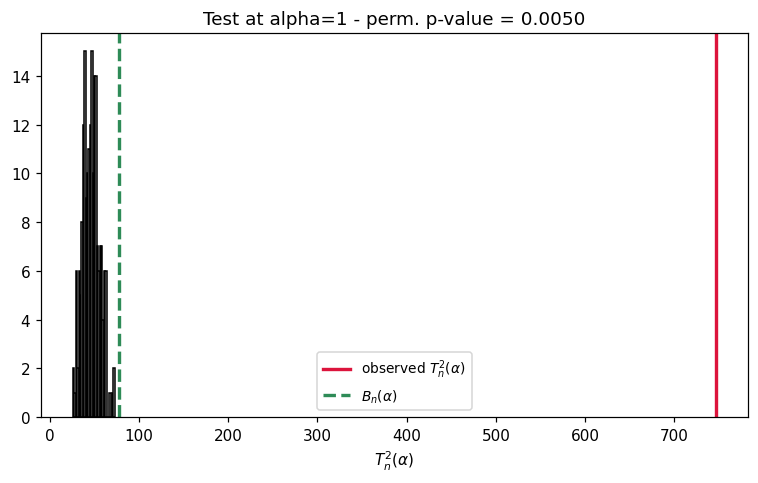

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(perm_reps, bins=30, color="lightgray", edgecolor="k")
ax.axvline(T2_obs, color="crimson", lw=2.2, label=r"observed $T_n^2(\alpha)$")
ax.axvline(B_n, color="seagreen", lw=2.2, ls="--", label=r"$B_n(\alpha)$")
ax.set_xlabel(r"$T_n^2(\alpha)$")
ax.set_title(f"Test at alpha={ALPHA_FIXED:g} - perm. p-value = {pval_perm:.4f}")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("fig_test_alpha_fixed.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 6. Sensitivity to $\alpha$

We vary $\alpha$ over a log grid and plot, as a function of $\alpha$:
- $T_n^2(\alpha)$ (observed statistic, single value - computed on the same $Z$)
- $B_n(\alpha, \delta)$ (Theorem 2.2 bound)
- the mean of the sign-flip permutation replications $\overline{T^{2,\text{perm}}_n(\alpha)}$

Sweeping alpha:   0%|          | 0/40 [00:00<?, ?it/s]

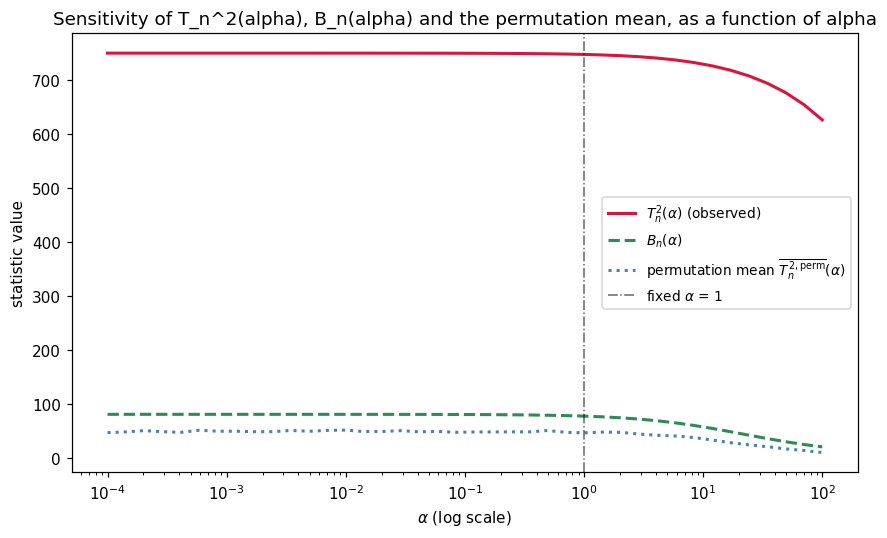

In [ ]:
alphas = np.logspace(-4, 2, 40)

T2_of_alpha = np.empty(len(alphas))
B_of_alpha = np.empty(len(alphas))
permmean_of_alpha = np.empty(len(alphas))

rng2 = np.random.default_rng(SEED + 3)
B_PERM = 49  # reduced a bit so the loop over alpha stays fast; increase if needed

for i, a in enumerate(tqdm(alphas, desc="Sweeping alpha")):
    T2a, Th1a, Th2a, Thinfa, _ = penalized_hotelling_stats(Z, a)
    Bna = rejection_bound(Th1a, Th2a, Thinfa, delta=DELTA)
    _, reps_a, _ = signflip_permutation(Z, a, B=B_PERM, rng=rng2)

    T2_of_alpha[i] = T2a
    B_of_alpha[i] = Bna
    permmean_of_alpha[i] = reps_a.mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(alphas, T2_of_alpha, color="crimson", lw=2, label=r"$T_n^2(\alpha)$ (observed)")
ax.semilogx(alphas, B_of_alpha, color="seagreen", lw=2, ls="--", label=r"$B_n(\alpha)$")
ax.semilogx(alphas, permmean_of_alpha, color="steelblue", lw=2, ls=":",
            label=r"permutation mean $\overline{T^{2,\mathrm{perm}}_n}(\alpha)$")
ax.axvline(ALPHA_FIXED, color="black", lw=1, ls="-.", alpha=0.6,
           label=fr"fixed $\alpha$ = {ALPHA_FIXED:g}")
ax.set_xlabel(r"$\alpha$ (log scale)")
ax.set_ylabel("statistic value")
ax.set_title("Sensitivity of T_n^2(alpha), B_n(alpha) and the permutation mean, as a function of alpha")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("fig_sensitivity_alpha.png", dpi=300, bbox_inches="tight")
plt.show()
